In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.linalg import cholesky

from lmpy import data, lm, lme, anova

## Examples from *lme4: Mixed-effects Modeling with R* (Bates, 2010)

### 1.3.1

In [2]:
Dyestuff = data('Dyestuff', 'lme4')
fm01 = lme('Yield ~ 1 + (1|Batch)', Dyestuff)              # REML default
fm01.summary()

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1|Batch)

REML criterion at convergence: 319.6543

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4117 -0.7634 0.1418 0.7792 1.8296

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1764     42.00
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    1527.5     19.3833   78.805


Same fit by ML

In [3]:
fm01ML = lme('Yield ~ 1 + (1|Batch)', Dyestuff, REML=False)
fm01ML.summary()

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1|Batch)

     AIC      BIC    logLik -2*log(L) df.resid
333.3271 337.5307 -163.6635  327.3271       27

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4315 -0.7972 0.1480 0.7721 1.8037

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1388     37.26
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    1527.5     17.6944   86.327


In [4]:
Dyestuff2 = data('Dyestuff2', 'lme4')
fm02 = lme('Yield ~ 1 + (1|Batch)', Dyestuff2)
fm02.summary()

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1|Batch)

REML criterion at convergence: 161.8283

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7648 -0.7806 -0.0809 0.6689 2.0907

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.81    3.716
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656      0.6784   8.3516


In [5]:
fm02ML = lme('Yield ~ 1 + (1|Batch)', Dyestuff2, REML=False)
fm02ML.summary()

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1|Batch)

     AIC      BIC   logLik -2*log(L) df.resid
168.8730 173.0766 -81.4365  162.8730       27

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7950 -0.7940 -0.0823 0.6803 2.1264

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.35    3.653
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656       0.667   8.4943


In [6]:
fm02a = lm('Yield ~ 1', Dyestuff2)
fm02a.summary()

Formula: Yield ~ 1

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t values  Pr(>|t|)
(Intercept)     5.666       0.678     4.278      7.053     8.352       0.0  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 1, Residual SE = 3.716 on 29 DF
R-Squared = 0.0000, adjusted R-Squared = 0.0000
Log Likelihood = -81.4365, AIC = 166.8730, BIC = 169.6754


### 1.4.2 Design Matrices

The book walks through the matrices the fit builds. For `fm01ML` (`Yield ~ 1 + (1|Batch)`, 30 obs over 6 batches):

- `X` — fixed-effects design, 30 × 1 (an intercept column),
- `Z` — random-effects design, 30 × 6 (indicators for `Batch`),
- `θ` — variance-component parameter (here a single scalar),
- `Λ(θ)` — relative covariance factor, 6 × 6; `Σ = σ² Λ Λᵀ`.

`X`, `Z`, and `θ` sit directly on the fitted object as `fm01ML.X`, `fm01ML.Z`, `fm01ML.theta`. `Λ` is built by plugging `θ` into the integer template `fm01ML._re.Lambdat`. The book images `Λ` (Fig. 1.3) and `Zᵀ` (Fig. 1.4) — non-zero cells filled, zero blank.

Z (30, 6)   Λ (6, 6)   θ = [0.7525665]


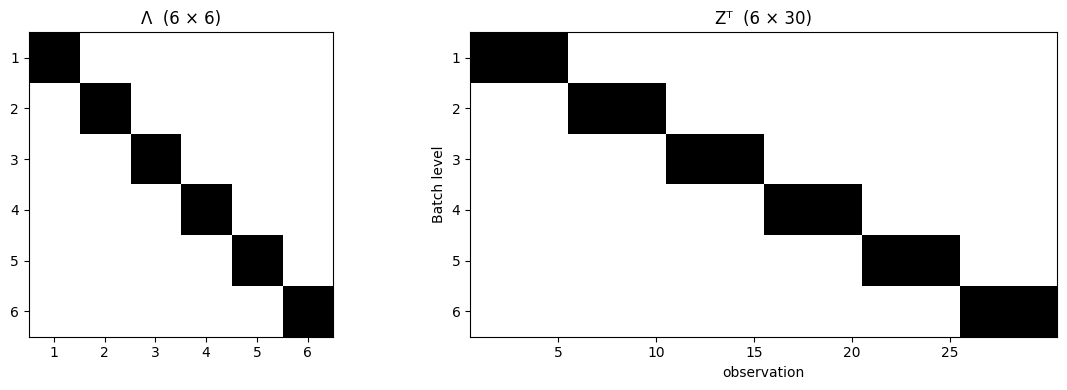

In [7]:
X     = fm01ML.X.to_numpy()
Z     = fm01ML.Z
theta = fm01ML.theta
# Λᵀ is reconstructed by plugging θ into an integer template:
tpl   = fm01ML._re.Lambdat
Lt    = np.zeros(tpl.shape)
Lt[tpl > 0] = theta[tpl[tpl > 0] - 1]
Lam   = Lt.T

print(f'Z {Z.shape}   Λ {Lam.shape}   θ = {theta}')

fig, ax = plt.subplot_mosaic(mosaic="AB", figsize=(12, 4))

ax["A"].imshow(Lam != 0, cmap='Greys', vmin=0, vmax=1)
ax["A"].set_title('Λ  (6 × 6)')
ax["A"].set_xticks(range(6))
ax["A"].set_yticks(range(6))
ax["A"].set_xticklabels(range(1, 7))
ax["A"].set_yticklabels(range(1, 7))

ax["B"].imshow(Z.T != 0, cmap='Greys', vmin=0, vmax=1, aspect='auto')
ax["B"].set_title('Zᵀ  (6 × 30)')
ax["B"].set_yticks(range(6))
ax["B"].set_yticklabels(range(1, 7))
ax["B"].set_xticks([4, 9, 14, 19, 24])
ax["B"].set_xticklabels([5, 10, 15, 20, 25])
ax["B"].set_xlabel('observation')
ax["B"].set_ylabel('Batch level')

plt.tight_layout()
plt.show()

In [8]:
Lt

array([[0.7525665, 0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.7525665, 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.7525665, 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.7525665, 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.7525665, 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       , 0.7525665]])

### 2.1.2

In [9]:
Penicillin = data('Penicillin', 'lme4')
fm03 = lme('diameter ~ 1 + (1|plate) + (1|sample)', Penicillin)
fm03.summary()

Linear mixed model fit by REML
Formula: diameter ~ 1 + (1|plate) + (1|sample)

REML criterion at convergence: 330.8606

Scaled residuals:
    Min      1Q Median     3Q    Max
-2.0792 -0.6714 0.0629 0.5838 2.9795

Random effects:
 Groups   Name        Variance Std.Dev.
 plate    (Intercept) 0.7163   0.8464
 sample   (Intercept) 3.7450   1.9352
 Residual             0.3024   0.5499
Number of obs: 144, groups:  plate, 24; sample, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   22.9722        0.81  28.3607


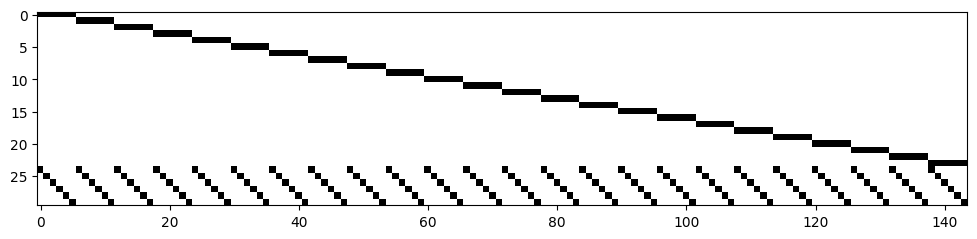

In [10]:
fig, ax = plt.subplots(figsize=(12,3))
ax.imshow(fm03.Z.T, cmap='Greys', vmin=0, vmax=1)

Z (144, 30)   Λ (30, 30)   θ = [1.53904501 3.51902846]


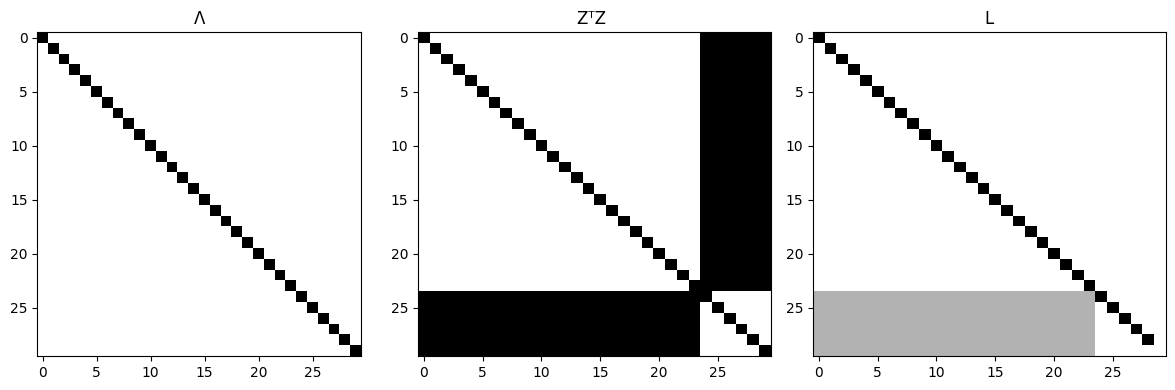

In [11]:
Z     = fm03.Z
theta = fm03.theta
tpl   = fm03._re.Lambdat
Lt    = np.zeros(tpl.shape)
Lt[tpl > 0] = theta[tpl[tpl > 0] - 1]
Lam   = Lt.T

ZtZ = Z.T @ Z
L = cholesky(ZtZ + 1e-16).T


print(f'Z {Z.shape}   Λ {Lam.shape}   θ = {theta}')

fig, ax = plt.subplot_mosaic(mosaic="ABC", figsize=(12, 4))

ax["A"].imshow(Lam != 0, cmap='Greys', vmin=0, vmax=1)
ax["A"].set_title('Λ')

ax["B"].imshow(Z.T @ Z, cmap='Greys', vmin=0, vmax=1, aspect='auto')
ax["B"].set_title('ZᵀZ ')

ax["C"].imshow(L, cmap='Greys', vmin=0, vmax=1, aspect='auto')
ax["C"].set_title('L')

plt.tight_layout()
plt.show()

### 2.2.3

In [12]:
Pastes = data('Pastes', 'lme4')
fm04  = lme('strength ~ 1 + (1|sample) + (1|batch)', Pastes, REML=False)
fm04.summary()

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1|sample) + (1|batch)

     AIC      BIC    logLik -2*log(L) df.resid
255.9945 264.3718 -123.9972  247.9945       56

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4847 -0.5262 0.0122 0.4674 1.3892

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 8.434    2.9042
 batch    (Intercept) 1.199    1.0949
 Residual             0.678    0.8234
Number of obs: 60, groups:  sample, 30; batch, 10

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533      0.6421  93.5235


In [13]:
fm04a = lme('strength ~ 1 + (1|sample)', Pastes, REML=False)
fm04a.summary()

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1|sample)

     AIC      BIC    logLik -2*log(L) df.resid
254.4017 260.6847 -124.2009  248.4017       57

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4916 -0.5416 0.0152 0.4618 1.3880

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 9.6298   3.1032
 Residual             0.6782   0.8235
Number of obs: 60, groups:  sample, 30

Fixed effects:
             Estimate  Std. Error   t value
(Intercept)   60.0533      0.5765  104.1777


In [14]:
chisq = fm04a.deviance - fm04.deviance
df    = fm04.npar - fm04a.npar
p     = chi2.sf(chisq, df)
print(f'LRT fm04a vs fm04:  chisq={chisq:.4f}  df={df}  p={p:.4f}')

LRT fm04a vs fm04:  chisq=0.4072  df=1  p=0.5234


### 2.3.1

In [15]:
InstEval = data("InstEval", "lme4")
fm05 = lme("y ~ 1 + (1|s) + (1|d) + (1|dept:service)", InstEval, REML=False)

In [16]:
fm05.summary()

Linear mixed model fit by maximum likelihood
Formula: y ~ 1 + (1|s) + (1|d) + (1|dept:service)

        AIC         BIC       logLik   -2*log(L) df.resid
237663.2918 237709.3116 -118826.6459 237653.2918    73416

Scaled residuals:
    Min      1Q Median     3Q    Max
-2.9941 -0.7474 0.0400 0.7721 3.1124

Random effects:
 Groups       Name        Variance Std.Dev.
 s            (Intercept) 0.10541  0.3247
 d            (Intercept) 0.26257  0.5124
 dept:service (Intercept) 0.01213  0.1101
 Residual                 1.38495  1.1768
Number of obs: 73421, groups:  s, 2972; d, 1128; dept:service, 28

Fixed effects:
             Estimate  Std. Error   t value
(Intercept)    3.2552      0.0282  115.2622


In [17]:
fm05a = lme("y ~ 1 + (1|s) + (1|d)", InstEval, REML=False)

In [18]:
fm05a.summary()

Linear mixed model fit by maximum likelihood
Formula: y ~ 1 + (1|s) + (1|d)

        AIC         BIC       logLik   -2*log(L) df.resid
237785.7260 237822.5418 -118888.8630 237777.7260    73417

Scaled residuals:
    Min      1Q Median     3Q    Max
-3.0203 -0.7469 0.0418 0.7733 3.1279

Random effects:
 Groups   Name        Variance Std.Dev.
 s        (Intercept) 0.1062   0.3259
 d        (Intercept) 0.2735   0.5230
 Residual             1.3872   1.1778
Number of obs: 73421, groups:  s, 2972; d, 1128

Fixed effects:
             Estimate  Std. Error   t value
(Intercept)    3.2542      0.0184  177.0178


### 3.2.1 A model with correlated random effects

In [19]:
sleepstudy = data('sleepstudy', 'lme4')
fm06 = lme('Reaction ~ 1 + Days + (1+Days|Subject)', sleepstudy, REML=False)
fm06.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1+Days|Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1763.9393 1783.0971 -875.9697 1751.9393      174

Scaled residuals:
    Min      1Q Median     3Q    Max
-3.9416 -0.4656 0.0289 0.4636 5.1793

Random effects:
 Groups   Name        Variance Std.Dev. Corr
 Subject  (Intercept) 565.51   23.780
          Days        32.68    5.717    0.08
 Residual             654.94   25.592
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)  251.4051      6.6323  37.9064
Days          10.4673      1.5022   6.9678

Correlation of Fixed Effects:
     (Intr)
Days -0.138


### 3.2.2 A model with uncorrelated random effects

In [20]:
fm07 = lme(
    'Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)',
    sleepstudy, REML=False,
)
fm07.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1762.0033 1777.9680 -876.0016 1752.0033      175

Scaled residuals:
    Min      1Q Median     3Q    Max
-3.9535 -0.4673 0.0239 0.4625 5.1883

Random effects:
 Groups    Name        Variance Std.Dev.
 Subject   (Intercept) 584.27   24.172
 Subject.1 Days        33.63    5.799
 Residual              653.12   25.556
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)  251.4051      6.7077  37.4798
Days          10.4673      1.5193   6.8895

Correlation of Fixed Effects:
     (Intr)
Days -0.194


In [21]:
anova(fm07, fm06)

Analysis of Variance Table (likelihood ratio test)

model 0: Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)
model 1: Reaction ~ 1 + Days + (1+Days|Subject)

         npar        AIC        BIC     logLik   deviance   Chisq  Df  Pr(>Chisq)
model 0     5  1762.0033  1777.9680  -876.0016  1752.0033
model 1     6  1763.9393  1783.0971  -875.9697  1751.9393  0.0639   1      0.8004
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 4.1

In [22]:
Machines = data('Machines', 'nlme')
fm08 = lme('score ~ Machine + (1|Worker)', Machines, REML=False)
fm09 = lme('score ~ Machine + (Machine|Worker)', Machines, REML=False)
fm10 = lme('score ~ Machine + (1|Worker) + (1|Machine:Worker)', Machines, REML=False)


In [23]:
anova(fm08, fm09, fm10)

Analysis of Variance Table (likelihood ratio test)

model 0: score ~ Machine + (1|Worker)
model 1: score ~ Machine + (Machine|Worker)
model 2: score ~ Machine + (1|Worker) + (1|Machine:Worker)

         npar       AIC       BIC     logLik  deviance    Chisq  Df  Pr(>Chisq)
model 0     5  303.7033  313.6482  -146.8516  293.7033
model 2     6  237.2695  249.2034  -112.6347  225.2695  68.4338   1   1.312e-16  ***
model 1    10  236.4179  256.3078  -108.2090  216.4179   8.8515   4     0.06492  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [24]:
fm10.summary()

Linear mixed model fit by maximum likelihood
Formula: score ~ Machine + (1|Worker) + (1|Machine:Worker)

     AIC      BIC    logLik -2*log(L) df.resid
237.2695 249.2034 -112.6347  225.2695       48

Scaled residuals:
    Min      1Q  Median     3Q    Max
-2.2587 -0.5513 -0.0065 0.4467 2.5486

Random effects:
 Groups         Name        Variance Std.Dev.
 Machine:Worker (Intercept) 11.5341  3.3962
 Worker         (Intercept) 19.0389  4.3634
 Residual                   0.9249   0.9617
Number of obs: 54, groups:  Machine:Worker, 18; Worker, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   52.3556      2.2687  23.0776
MachineB       7.9667      1.9868   4.0098
MachineC      13.9167      1.9868   7.0045

Correlation of Fixed Effects:
           (Intr) MachineB
MachineB   -0.438
MachineC   -0.438    0.500


### 4.2

In [25]:
ergoStool = data('ergoStool', 'nlme')
fm16 = lme('effort ~ 1 + (1|Subject) + (1|Type)', ergoStool, REML=False)
fm16.summary()

Linear mixed model fit by maximum likelihood
Formula: effort ~ 1 + (1|Subject) + (1|Type)

     AIC      BIC   logLik -2*log(L) df.resid
144.0224 150.3564 -68.0112  136.0224       32

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.8844 -0.6881 0.0672 0.6782 1.6593

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 1.704    1.305
 Type     (Intercept) 2.265    1.505
 Residual             1.213    1.101
Number of obs: 36, groups:  Subject, 9; Type, 4

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)     10.25      0.8884  11.5382


In [26]:
fm16a = lme('effort ~ 1 + (1|Subject)', ergoStool, REML=False)
fm16a.summary()

Linear mixed model fit by maximum likelihood
Formula: effort ~ 1 + (1|Subject)

     AIC      BIC   logLik -2*log(L) df.resid
165.4474 170.1980 -79.7237  159.4474       33

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.4667 -1.0154 -0.1128 0.7898 2.1437

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 0.00     0.000
 Residual             4.91     2.216
Number of obs: 36, groups:  Subject, 9

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)     10.25      0.3693  27.7553


In [27]:
anova(fm16a, fm16)

Analysis of Variance Table (likelihood ratio test)

model 0: effort ~ 1 + (1|Subject)
model 1: effort ~ 1 + (1|Subject) + (1|Type)

         npar       AIC       BIC    logLik  deviance   Chisq  Df  Pr(>Chisq)
model 0     3  165.4474  170.1980  -79.7237  159.4474
model 1     4  144.0224  150.3564  -68.0112  136.0224  23.425   1   1.299e-06  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [28]:
fm17 = lme('effort ~ 1 + Type + (1|Subject)', ergoStool, REML=False)
fm17.summary()

Linear mixed model fit by maximum likelihood
Formula: effort ~ 1 + Type + (1|Subject)

     AIC      BIC   logLik -2*log(L) df.resid
134.1444 143.6456 -61.0722  122.1444       30

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.9113 -0.6822 0.0613 0.7435 1.7304

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 1.578    1.256
 Residual             1.076    1.037
Number of obs: 36, groups:  Subject, 9

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    8.5556      0.5431  15.7541
TypeT2         3.8889      0.4890   7.9524
TypeT3         2.2222      0.4890   4.5442
TypeT4         0.6667      0.4890   1.3633

Correlation of Fixed Effects:
       (Intr) TypeT2 TypeT3
TypeT2 -0.450
TypeT3 -0.450  0.500
TypeT4 -0.450  0.500  0.500
